# 选择模型

## 训练曲线展示

In [37]:
import os
import pandas as pd

data_path = "./model_param_alldata/"
base_name = "GTmining_6_6_GTB_fold"

validation_data = []
for fold in range(1, 11):
    folder_name = f"{base_name}{fold}"
    tsv_filename = os.path.join(data_path, folder_name, 'validation_log.csv')
    df = pd.read_csv(tsv_filename)
    validation_data.append(df['validation_f1_score'].to_list())



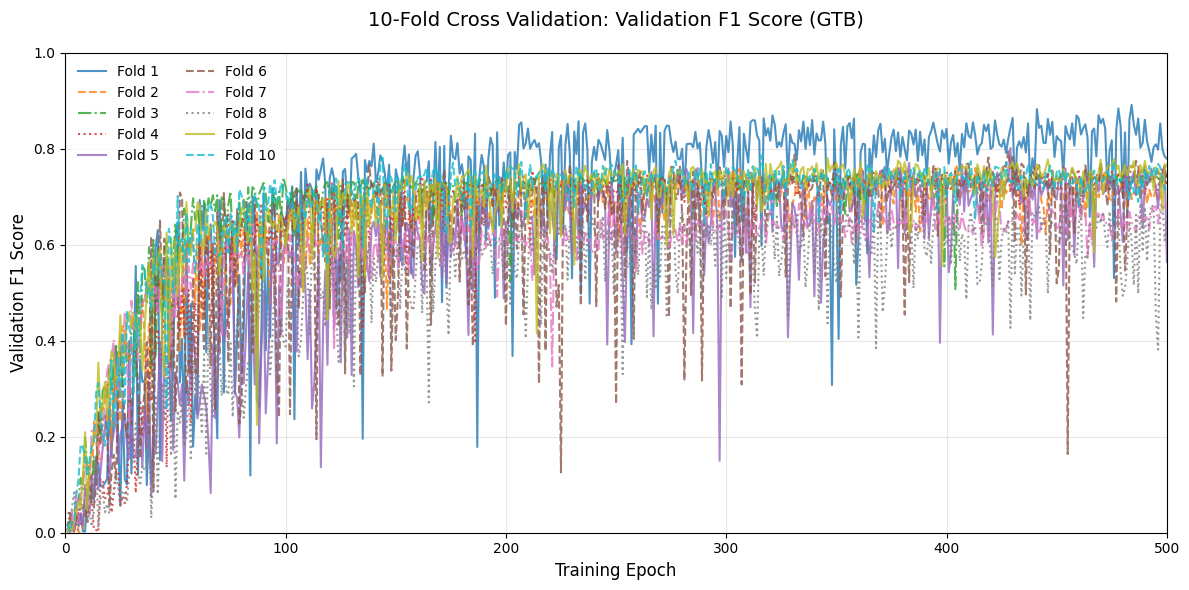

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===================== 1. 替换为你的真实数据 =====================
# 示例：10个嵌套列表，每个子列表是某一折的validation_f1_score（长度为训练轮次）
# 你需将下面的示例数据替换成自己的10折F1分数列表
val_f1_scores = validation_data

# ===================== 2. 配置绘图样式（10种不同颜色+线型+标记） =====================
# 10种区分度高的颜色（matplotlib tab10配色，适配10折）
colors = plt.cm.tab10(np.linspace(0, 1, 10))
# 10种不同线型（确保视觉区分）
linestyles = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--']
# 10种不同标记（增强区分度）
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'h', '+', 'x']

# ===================== 3. 绘制折线图 =====================
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # 解决中文显示（无中文可删）
plt.figure(figsize=(12, 6))  # 画布大小：宽12，高6

# 循环绘制每折的F1分数折线
for fold_idx in range(10):
    # 获取当前折的F1分数
    f1 = val_f1_scores[fold_idx]
    # 训练轮次（x轴，长度与F1分数一致）
    epochs = range(1, len(f1) + 1)
    
    # 绘制折线：颜色+线型+标记+标签
    plt.plot(
        epochs, f1,
        color=colors[fold_idx],
        linestyle=linestyles[fold_idx],
        # marker=markers[fold_idx],
        label=f'Fold {fold_idx + 1}',  # 图例标签：Fold 1 ~ Fold 10
        linewidth=1.5,  # 线条宽度
        alpha=0.8,
        # markersize=6    # 标记大小
    )

# ===================== 4. 图表美化与标注 =====================
plt.title('10-Fold Cross Validation: Validation F1 Score (GTB)', fontsize=14, pad=20)
plt.xlabel('Training Epoch', fontsize=12)
plt.ylabel('Validation F1 Score', fontsize=12)
plt.ylim(0, 1)  # y轴范围
plt.xlim(0, 500)  # x轴范围
plt.grid(True, alpha=0.3)  # 网格线（增强可读性）
plt.legend(loc='upper left', ncol=2, edgecolor='white')  # 图例：右下位置，2列展示（避免拥挤）
plt.tight_layout()  # 自动调整布局（防止标签重叠）

# ===================== 5. 保存/显示图表 =====================
# plt.savefig('./result/10fold_val_f1_score_GTB.png', dpi=1200, bbox_inches='tight')  # 保存为高清PNG
# plt.savefig('./result/10fold_val_f1_score_GTB.svg', bbox_inches='tight')  # 保存为SVG
plt.show()  # 显示图表


## 模型epoch逐条预测

In [1]:
import argparse
import textwrap
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import pandas as pd

import os
import pandas as pd

def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )

def prepare_data_one(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=1,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )

def train(dataset, model, prog_args, val_dataset=None):
    """
    training function
    """
    # 初始化模型存储路径
    if not os.path.exists(prog_args.save_dir + "/" + prog_args.dataset):
        os.makedirs(prog_args.save_dir + "/" + prog_args.dataset)
    else:
        shutil.rmtree(prog_args.save_dir + "/" + prog_args.dataset)
        os.makedirs(prog_args.save_dir + "/" + prog_args.dataset)

    f_train_log = open(prog_args.save_dir + "/" + prog_args.dataset + "/train_log.csv", 'w')
    temp_line = 'epoch, accuracy, F1 score'
    line_flag = 3
    if prog_args.family_fold_type == 'GTA':
        for x in range(1, 10):
            temp_line = temp_line + f', Class {x} F1 score'
            line_flag += 1
    elif prog_args.family_fold_type == 'GTB':
        for x in range(1, 11):
            temp_line = temp_line + f', Class {x} F1 score'
            line_flag += 1
    else:
        raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")
    temp_line = temp_line + '\n'
    f_train_log.write(temp_line)

    # 检查存储路径
    dir = prog_args.save_dir + "/" + prog_args.dataset
    if not os.path.exists(dir):
        os.makedirs(dir)
    
    dataloader = dataset
    optimizer = torch.optim.Adadelta(filter(lambda p: p.requires_grad, model.parameters()))  # 初始化优化器

    if prog_args.cuda > 0:
        torch.cuda.set_device(0)
    
    for epoch in range(0, prog_args.epoch):
        # 暂时存储，方便计算准确性
        train_pred_indi = torch.tensor([], device='cuda')
        train_label_indi = torch.tensor([], device='cuda')
        begin_time = time.time()
        model.train()
        accum_correct = 0
        total = 0
        print("\nEPOCH ###### {} ######".format(epoch))
        computation_time = 0.0
        for batch_idx, (batch_graph, graph_labels) in enumerate(dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()

            model.zero_grad()
            compute_start = time.time()
            ypred = model(batch_graph)
            indi = torch.argmax(ypred, dim=1)
            train_pred_indi = torch.cat((train_pred_indi, indi), dim=0)
            train_label_indi = torch.cat((train_label_indi, graph_labels), dim=0)
            correct = torch.sum(indi == graph_labels).item()
            accum_correct += correct
            total += graph_labels.size()[0]
            loss = model.loss(ypred, graph_labels)
            loss.backward()
            batch_compute_time = time.time() - compute_start
            computation_time += batch_compute_time
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
            optimizer.step()
        
        train_f1_score = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average='macro')
        temp_f1_score = f1_score(train_pred_indi.cpu(), train_label_indi.cpu(), average=None)
        train_f1_score_class_dict = {}
        train_f1_score_class_keys = []
        for i in range(len(temp_f1_score)):
            # 生成与原变量名相同的key，如"train_f1_score_class_1"
            key = f"train_f1_score_class_{i+1}"
            # 存储对应的值（i是列表索引，i+1是类别编号）
            train_f1_score_class_keys.append(key) # 列表是有先后顺序的，保证写入log的时候不会乱序
            train_f1_score_class_dict[key] = temp_f1_score[i]
        train_accu = accum_correct / total

        elapsed_time = time.time() - begin_time

        if prog_args.save_dir is not None:
            torch.save(
                model.state_dict(),
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(epoch)
            )

        temp_line = f'{epoch}, {train_accu * 100}, {train_f1_score}'
        temp_line_flag = 3
        for x in train_f1_score_class_keys:
            temp_line = temp_line + f', {train_f1_score_class_dict[x]}'
            temp_line_flag += 1
        temp_line = temp_line + '\n'
        assert temp_line_flag == line_flag, 'Wrong log line number, please check what happen.'
        f_train_log.write(temp_line)

        print("train accuracy for this epoch {} is {:.2f}%".format(epoch, train_accu * 100))
        print("loss {:.4f} with epoch time {:.4f} s & computation time {:.4f} s ".format(loss.item(), elapsed_time, computation_time))

        torch.cuda.empty_cache()
    f_train_log.close()
    return 'Trian successfully'



# ========================================
data_path = "./model_param_alldata/"
fold_num = 1
family_fold_type = 'GTA'
base_name = f"GTmining_6_6_{family_fold_type}_fold"
folder_name = f"{base_name}{fold_num}"
# ========================================

print("{:=^100}".format(f'fold num is : {fold_num}, family type is : {family_fold_type}'))

print("{:=^100}".format('prog_args'))
prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                   raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data_one(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data_one(dataset_test, shuffle=False, prog_args=prog_args)


input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_validation, label_dim_validation, max_num_node_validation = dataset_validation.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_validation, max_num_node_test])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_validation)+ len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


===============================fold num is : 1, family type is : GTA================================
=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTA_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTA')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 9
the max num node is 537
number of graphs is 11489
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 53


In [2]:
# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()



model init finished
MODEL::::::: diffpool


In [4]:
epoch = 909

begin_time = time.time()
print("\nEPOCH ###### {} ######".format(epoch))
if epoch is not None and prog_args.save_dir is not None:
    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(epoch), weights_only=True
        )
    )

id_card_protein = {}
# validation test
with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
    for dd in f.readlines():
        dd = dd.split('\n')[0].split('===')
        id_card_protein[dd[1]] = dd[0]


model.eval()
correct_label = 0
with torch.no_grad():
    val_pred_indi = torch.tensor([], device='cuda')
    val_label_indi = torch.tensor([], device='cuda')
    for batch_idx, (batch_graph, graph_labels) in enumerate(validation_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()

        # 拿标签
        temp = batch_graph
        protein_temp_id_card = ''
        protein_temp_id_card = protein_temp_id_card + "{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][0][0]), 5),
                                                                                                                                round(float(temp.ndata['feat'][0][1]), 5),
                                                                                                                                round(float(temp.ndata['feat'][0][2]), 5),
                                                                                                                                round(float(temp.ndata['feat'][0][3]), 5),
                                                                                                                                round(float(temp.ndata['feat'][0][4]), 5),
                                                                                                                                round(float(temp.ndata['feat'][0][5]), 5),
                                                                                                                                round(float(temp.ndata['feat'][0][6]), 5))
        protein_temp_id_card = protein_temp_id_card + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][1][0]), 5),
                                                                                                                                round(float(temp.ndata['feat'][1][1]), 5),
                                                                                                                                round(float(temp.ndata['feat'][1][2]), 5),
                                                                                                                                round(float(temp.ndata['feat'][1][3]), 5),
                                                                                                                                round(float(temp.ndata['feat'][1][4]), 5),
                                                                                                                                round(float(temp.ndata['feat'][1][5]), 5),
                                                                                                                                round(float(temp.ndata['feat'][1][6]), 5))
        protein_temp_id_card = protein_temp_id_card + "###{:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}, {:>.2f}".format(round(float(temp.ndata['feat'][2][0]), 5),
                                                                                                                                round(float(temp.ndata['feat'][2][1]), 5),
                                                                                                                                round(float(temp.ndata['feat'][2][2]), 5),
                                                                                                                                round(float(temp.ndata['feat'][2][3]), 5),
                                                                                                                                round(float(temp.ndata['feat'][2][4]), 5),
                                                                                                                                round(float(temp.ndata['feat'][2][5]), 5),
                                                                                                                                round(float(temp.ndata['feat'][2][6]), 5))
        protein_id = id_card_protein[protein_temp_id_card]


        ypred = model(batch_graph)
        indi = torch.argmax(ypred, dim=1)

        val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
        val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
        correct = torch.sum(indi == graph_labels)
        correct_label += correct.item()

        # print(f"Protein name is : {protein_id}, and its activate is {int(indi.cpu())}.")
        
elapsed_time = time.time() - begin_time
print("epoch {:.4f} with epoch time {:.4f} s".format(epoch, elapsed_time))
result = correct_label / len(validation_dataloader.dataset)

# model.eval()
# correct_label = 0
# with torch.no_grad():
#     val_pred_indi = torch.tensor([], device='cuda')
#     val_label_indi = torch.tensor([], device='cuda')
#     for batch_idx, (batch_graph, graph_labels) in enumerate(validation_dataloader):
#         for key, value in batch_graph.ndata.items():
#             batch_graph.ndata[key] = value.float()
#         graph_labels = graph_labels.long()
#         if torch.cuda.is_available():
#             batch_graph = batch_graph.to(torch.cuda.current_device())
#             graph_labels = graph_labels.cuda()
#         ypred = model(batch_graph)
#         indi = torch.argmax(ypred, dim=1)
#         val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
#         val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
#         correct = torch.sum(indi == graph_labels)
#         correct_label += correct.item()
#     val_f1_score = f1_score(val_pred_indi.cpu(), val_label_indi.cpu(), average='macro')


EPOCH ###### 909 ######
epoch 909.0000 with epoch time 69.1788 s


In [5]:
result

0.6532329495128433

# 绘制图像

## ROC曲线

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTB'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'
error_fold = 0
for fold in range(1, 11):
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    if fold == 3:
        continue
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[fold] = beat_epoch
    print(f"Fold type {fold_type}, Fold: {fold}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")


Fold type GTB, Fold: 1, Max Val F1 Score: 0.8913334586680826, Best Epoch: 483
Fold type GTB, Fold: 2, Max Val F1 Score: 0.7663228224239236, Best Epoch: 404
Fold type GTB, Fold: 4, Max Val F1 Score: 0.7684039384517768, Best Epoch: 483
Fold type GTB, Fold: 5, Max Val F1 Score: 0.8018020886744562, Best Epoch: 428
Fold type GTB, Fold: 6, Max Val F1 Score: 0.7950383478817663, Best Epoch: 427
Fold type GTB, Fold: 7, Max Val F1 Score: 0.7079288659362848, Best Epoch: 393
Fold type GTB, Fold: 8, Max Val F1 Score: 0.6974633264704687, Best Epoch: 302
Fold type GTB, Fold: 9, Max Val F1 Score: 0.7810649361245214, Best Epoch: 345
Fold type GTB, Fold: 10, Max Val F1 Score: 0.7861377751822867, Best Epoch: 315


In [3]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )



In [8]:
fold_num

3

In [21]:
from sklearn.metrics import auc, roc_curve

roc_history_dict = {0: [], 1: [], 2: [], 3: [], 4: [], 5: [], 6: [], 7: [], 8: [], 9: []}

for fold_num in range(1, 11):
    if fold_num == 3:
        continue
    param_folder = f'{log_save_folder}{fold}'
    print("{:=^100}".format('prog_args'))
    # 尝试
    prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                               batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                               dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                               load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
    print(textwrap.fill(str(prog_args), width=100))

    print("{:=^100}".format('加载数据'))
    dataset_train = tu.LegacyTUDataset(name="GTmining",
                                        raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
    dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
    dataset_test = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
    train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
    validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
    test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

    input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
    input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
    input_dim_realtest, label_dim_realtest, max_num_node_realtest = dataset_test.statistics()
    max_num_node = max([max_num_node_train, max_num_node_test, max_num_node_realtest])
    input_dim = input_dim_train
    label_dim = label_dim_train
    print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
    print("dataset feature dimension is", input_dim_train)
    print("dataset label dimension is", label_dim_train)
    print("the max num node is", max_num_node)
    print("number of graphs is", len(dataset_train) + len(dataset_test))

    hidden_dim = prog_args.hidden_dim  # used to be 64
    embedding_dim = prog_args.embedding_dim

    assign_dim = int(max_num_node * prog_args.pool_ratio)
    print("++++++++++MODEL STATISTICS++++++++")
    print("model hidden dim is", hidden_dim)
    print("model embedding dim for graph instance embedding", embedding_dim)
    print("initial batched pool graph dim is", assign_dim)
    activation = F.relu

    if family_fold_type == 'GTA':
        graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                            'UDP-Gal': 3, 'UDP-GalNAc': 4,
                            'UDP-Xyl': 5, 'GDP-Man': 6,
                            'dTDP-Rha': 7, 'Other': 8}
    elif family_fold_type == 'GTB':
        graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                            'UDP-Gal': 3, 'UDP-GalNAc': 4,
                            'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                            'dTDP-Rha': 8, 'Other': 9}
    else:
        raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

    df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
    df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
    df_cluster.reset_index(drop=True, inplace=True)
    custom_loss_weight = []
    total_sample = df_cluster.shape[0]
    for x in graph_label_dict.keys():
        df_x = df_cluster.loc[df_cluster['Activate']==x]
        df_x.reset_index(drop=True, inplace=True)
        x_sample = df_x.shape[0]
        custom_loss_weight.append(total_sample/x_sample)

    assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

    # initialize model
    model = DiffPool(
        input_dim,
        hidden_dim,
        embedding_dim,
        label_dim,
        activation,
        prog_args.gc_per_block,
        prog_args.dropout,
        prog_args.num_pool,
        prog_args.linkpred,
        prog_args.batch_size,
        prog_args.aggregator_type,
        assign_dim,
        prog_args.pool_ratio,
        custom_loss_weight
    )
    print("model init finished")
    print("MODEL:::::::", prog_args.method)
    if prog_args.cuda:
        model = model.cuda()

    # 先过一遍train_dataloader，让模型中的一些参数先初始化一下
    model.train()
    for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
        for key, value in batch_graph.ndata.items():
            batch_graph.ndata[key] = value.float()
        graph_labels = graph_labels.long()
        if torch.cuda.is_available():
            batch_graph = batch_graph.to(torch.cuda.current_device())
            graph_labels = graph_labels.cuda()
        ypred = model(batch_graph)
        loss = model.loss(ypred, graph_labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
        model.zero_grad()

    epoch = best_epochs[fold_num]

    begin_time = time.time()
    print("\nEPOCH ###### {} ######".format(epoch))
    if epoch is not None and prog_args.save_dir is not None:
        model.load_state_dict(
            torch.load(
                prog_args.save_dir
                + "/"
                + prog_args.dataset
                + "/model.iter-"
                + "{:04d}".format(epoch), weights_only=True
            )
        )

    id_card_protein = {}
    # validation test
    with open(f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/Predict_correspond_information.txt', 'r')as f:
        for dd in f.readlines():
            dd = dd.split('\n')[0].split('===')
            id_card_protein[dd[1]] = dd[0]

    model.eval()
    correct_label = 0
    with torch.no_grad():
        val_pred_indi = torch.tensor([], device='cuda')
        val_label_indi = torch.tensor([], device='cuda')
        val_pred_proba = torch.tensor([], device='cuda')
        for batch_idx, (batch_graph, graph_labels) in enumerate(test_dataloader):
            for key, value in batch_graph.ndata.items():
                batch_graph.ndata[key] = value.float()
            graph_labels = graph_labels.long()
            if torch.cuda.is_available():
                batch_graph = batch_graph.to(torch.cuda.current_device())
                graph_labels = graph_labels.cuda()
            ypred = model(batch_graph)
            ypred_proba = torch.nn.Softmax(dim=1)(ypred)
            indi = torch.argmax(ypred, dim=1)
            val_pred_indi = torch.cat((val_pred_indi, indi), dim=0)
            val_label_indi = torch.cat((val_label_indi, graph_labels), dim=0)
            val_pred_proba = torch.cat((val_pred_proba, ypred_proba), dim=0)
            correct = torch.sum(indi == graph_labels)
            correct_label += correct.item()
    
    # for plot_flag in range(9):
    for plot_flag in range(10):
        y_test_temp = []
        for i in range(len(val_label_indi)):
            if int(val_label_indi[i]) == plot_flag:
                y_test_temp.append(1)
            else:
                y_test_temp.append(0)
        t_fpr, t_tpr, thre = roc_curve(y_test_temp, val_pred_proba.cpu()[:, plot_flag])
        roc_history_dict[plot_flag].append([t_fpr, t_tpr, thre])
        

    # break

=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold1', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTB')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 655
number of graphs is 16122
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 65
model init finished
MODEL::::::: diffpool

EPOCH ###### 483 ######
============================================

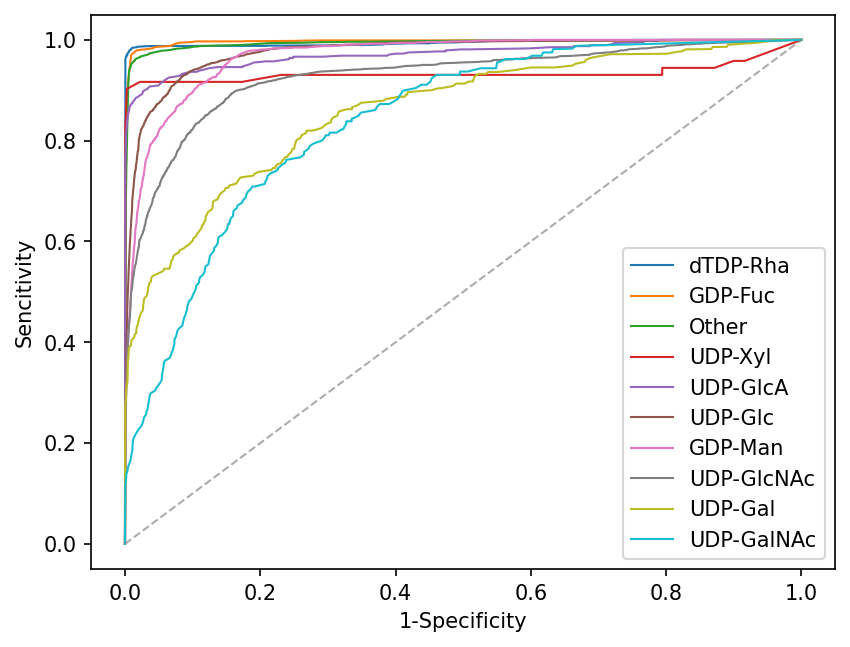

In [24]:
import matplotlib.pyplot as plt

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")
graph_label_dict = {v: k for k, v in graph_label_dict.items()}

plt.figure(dpi=150)
for plot_flag in [8,7,9,5,2,0,6,1,3,4]:
    roc_history = roc_history_dict[plot_flag]
    auc_history, value, fpr, tpr = [], [], [], []
    for t_fpr, t_tpr, thre in roc_history:
        #计算AUC
        auc_score = auc(t_fpr, t_tpr)
        auc_history.append(auc_score)
        fpr.append([float(i) for i in t_fpr])
        value.extend([float(i) for i in t_fpr])
        tpr.append([float(i) for i in t_tpr])

    mean_fpr, min_fpr, max_fpr = [],[],[]
    mean_tpr, min_tpr, max_tpr= [],[],[]
    #这个是为了对曲线进行插值，因为每个曲线的样本不一样，所以获取到的fpr和tpr也不一样长度，
    #所以需要进行插值
    #插值的原理是，获取所有fpr的值，然后将每个交叉验证的roc都插值成和fpr的值一样多的长度。
    #插值并不会改变每个roc曲线的形状，这个可以放心使用
    unique = np.unique(np.array(value).flatten())
    #对fpr和tpr进行插值
    for l in range(len(fpr)):
        tpr[l] = np.interp(unique, fpr[l], tpr[l], 0, 1)
        fpr[l] = np.interp(unique, fpr[l], fpr[l], 0, 1)
        #将每个交叉验证的ROC都画出来
        # plt.plot(fpr[l], tpr[l])

    fpr = np.array(fpr)
    tpr = np.array(tpr)
    #求fpr和tpr的极大极小，获取每个实验所能触及的最大指标范围
    min_fpr = np.min(fpr, axis=0)
    max_fpr = np.max(fpr, axis=0)
    min_tpr = np.min(tpr, axis=0)
    max_tpr = np.max(tpr, axis=0)
    #获取均值，为了得到交叉验证的平均曲线
    mean_tpr = np.mean(tpr, axis=0)
    mean_fpr = np.mean(fpr, axis=0)
    mean_tpr[0] = 0

    
    # plt.title(graph_label_dict[plot_flag])
    plt.xlabel('1-Specificity')
    plt.ylabel('Sencitivity')
    #画平均曲线
    plt.plot(mean_fpr, mean_tpr, marker=None,
            linewidth=1,
            alpha=1, label=graph_label_dict[plot_flag])#markeredgecolor='b',
    
plt.plot(np.linspace(0, 1, 10), np.linspace(0, 1, 10), linestyle='--',c='grey', linewidth=1, alpha=0.65)

plt.legend(loc='lower right')
#展示图象
output_path = f'./result/20251211-roc-GTB.png'
plt.savefig(output_path, dpi=1200)
output_path = f'./result/20251211-roc-GTB.svg'
plt.savefig(output_path, format='svg', dpi=1200)
plt.show()

    # break

In [19]:
roc_history_dict

{0: [[array([0.        , 0.00935745, 0.01060512, 0.01060512, 0.01060512,
          0.01060512, 0.01060512, 0.01060512, 0.01060512, 0.01122895,
          0.01122895, 0.01185278, 0.01185278, 0.01185278, 0.01185278,
          0.01185278, 0.01185278, 0.01185278, 0.01185278, 0.01247661,
          0.01247661, 0.01310044, 0.01310044, 0.01372427, 0.01372427,
          0.01497193, 0.01497193, 0.01559576, 0.01559576, 0.01871491,
          0.01871491, 0.01933874, 0.01933874, 0.01996257, 0.01996257,
          0.02121023, 0.02121023, 0.02183406, 0.02183406, 0.02245789,
          0.02245789, 0.02308172, 0.02308172, 0.02557704, 0.02557704,
          0.02744853, 0.02744853, 0.02807236, 0.02807236, 0.02869619,
          0.02869619, 0.02932002, 0.02932002, 0.02994386, 0.02994386,
          0.03056769, 0.03056769, 0.03181535, 0.03181535, 0.03431067,
          0.03431067, 0.03680599, 0.03680599, 0.03742982, 0.03742982,
          0.03867748, 0.03867748, 0.03930131, 0.03930131, 0.04054897,
          0.04054

# 废物

## GTB的fold3好像加载不上来

In [1]:
import argparse
import os
import time
import dgl
import torch
import torch.nn as nn
import torch.nn.functional as F
from dgl.data import tu
from model.encoder import DiffPool
from sklearn.metrics import f1_score
import shutil
import argparse
import os
import random
import time

import dgl
import dgl.function as fn

import networkx as nx
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data
from dgl import DGLGraph
from dgl.data import tu
from model.encoder import DiffPool
from livelossplot import PlotLosses
from sklearn.metrics import f1_score
import shutil
import textwrap

import sys
# 获取命令行参数


/home/admin123/software/miniconda3/envs/GTmining_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os
import pandas as pd

best_epochs = {}
fold_type = 'GTB'
family_fold_type = fold_type
log_save_folder = f'GTmining_6_6_{fold_type}_fold'
error_fold = 0
for fold in range(1, 11):
    log_dir = f'./model_param_alldata/{log_save_folder}{fold}/validation_log.csv'
    df = pd.read_csv(log_dir, index_col=False)
    max_val_f1_score = df['validation_f1_score'].max()
    
    beat_epoch = df['epoch'].loc[df['validation_f1_score'] == max_val_f1_score].values[0]
    best_epochs[fold] = beat_epoch
    print(f"Fold type {fold_type}, Fold: {fold}, Max Val F1 Score: {max_val_f1_score}, Best Epoch: {beat_epoch}")


Fold type GTB, Fold: 1, Max Val F1 Score: 0.8913334586680826, Best Epoch: 483
Fold type GTB, Fold: 2, Max Val F1 Score: 0.7663228224239236, Best Epoch: 404
Fold type GTB, Fold: 3, Max Val F1 Score: 0.7536282530466846, Best Epoch: 462
Fold type GTB, Fold: 4, Max Val F1 Score: 0.7684039384517768, Best Epoch: 483
Fold type GTB, Fold: 5, Max Val F1 Score: 0.8018020886744562, Best Epoch: 428
Fold type GTB, Fold: 6, Max Val F1 Score: 0.7950383478817663, Best Epoch: 427
Fold type GTB, Fold: 7, Max Val F1 Score: 0.7079288659362848, Best Epoch: 393
Fold type GTB, Fold: 8, Max Val F1 Score: 0.6974633264704687, Best Epoch: 302
Fold type GTB, Fold: 9, Max Val F1 Score: 0.7810649361245214, Best Epoch: 345
Fold type GTB, Fold: 10, Max Val F1 Score: 0.7861377751822867, Best Epoch: 315


In [3]:
def prepare_data(dataset, shuffle=False, prog_args=None):
    """
    preprocess TU dataset according to DiffPool's paper setting and load dataset into dataloader
    """
    return dgl.dataloading.GraphDataLoader(
        dataset,
        batch_size=prog_args.batch_size,
        shuffle=shuffle,
        num_workers=prog_args.n_worker,
    )



In [5]:
fold_num = 4

param_folder = f'{log_save_folder}{fold}'
print("{:=^100}".format('prog_args'))
# 尝试
prog_args = argparse.Namespace(dataset=f'GTmining_6_6_{family_fold_type}_fold{fold_num}', pool_ratio=0.10, num_pool=1, cuda=1, lr=1.0, clip=float("inf"),
                            batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type="meanpool",
                            dropout=0.00, method="diffpool", bn=True, bias=True, save_dir=f"./model_param_alldata",
                            load_epoch=-1, data_mode="default", linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type=family_fold_type)
print(textwrap.fill(str(prog_args), width=100))

print("{:=^100}".format('加载数据'))
dataset_train = tu.LegacyTUDataset(name="GTmining",
                                    raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/train/')
dataset_validation = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/validation/')
dataset_test = tu.LegacyTUDataset(name="GTmining",
                                raw_dir=f'../data/dl_data/{family_fold_type}_alldata/fold{fold_num}/test/')
train_dataloader = prepare_data(dataset_train, shuffle=True, prog_args=prog_args)
validation_dataloader = prepare_data(dataset_validation, shuffle=False, prog_args=prog_args)
test_dataloader = prepare_data(dataset_test, shuffle=False, prog_args=prog_args)

input_dim_train, label_dim_train, max_num_node_train = dataset_train.statistics()
input_dim_test, label_dim_test, max_num_node_test = dataset_test.statistics()
input_dim_realtest, label_dim_realtest, max_num_node_realtest = dataset_test.statistics()
max_num_node = max([max_num_node_train, max_num_node_test, max_num_node_realtest])
input_dim = input_dim_train
label_dim = label_dim_train
print("++++++++++ STATISTICS ABOUT THE DATASET ++++++++++")
print("dataset feature dimension is", input_dim_train)
print("dataset label dimension is", label_dim_train)
print("the max num node is", max_num_node)
print("number of graphs is", len(dataset_train) + len(dataset_test))

hidden_dim = prog_args.hidden_dim  # used to be 64
embedding_dim = prog_args.embedding_dim

assign_dim = int(max_num_node * prog_args.pool_ratio)
print("++++++++++MODEL STATISTICS++++++++")
print("model hidden dim is", hidden_dim)
print("model embedding dim for graph instance embedding", embedding_dim)
print("initial batched pool graph dim is", assign_dim)
activation = F.relu

if family_fold_type == 'GTA':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6,
                        'dTDP-Rha': 7, 'Other': 8}
elif family_fold_type == 'GTB':
    graph_label_dict = {'UDP-Glc': 0, 'UDP-GlcNAc': 1, 'UDP-GlcA': 2,
                        'UDP-Gal': 3, 'UDP-GalNAc': 4,
                        'UDP-Xyl': 5, 'GDP-Man': 6, 'GDP-Fuc': 7,
                        'dTDP-Rha': 8, 'Other': 9}
else:
    raise ValueError(f"Invalid family_fold_type: '{prog_args.family_fold_type}'. Valid options are 'GTA' and 'GTB'.")

df_cluster = pd.read_excel(f'../data/cluster/{family_fold_type}/dataseat_split_{fold_num}.xlsx')
df_cluster = df_cluster.loc[df_cluster['Dataset']=='train']
df_cluster.reset_index(drop=True, inplace=True)
custom_loss_weight = []
total_sample = df_cluster.shape[0]
for x in graph_label_dict.keys():
    df_x = df_cluster.loc[df_cluster['Activate']==x]
    df_x.reset_index(drop=True, inplace=True)
    x_sample = df_x.shape[0]
    custom_loss_weight.append(total_sample/x_sample)

assert len(custom_loss_weight) == label_dim_train, 'Wrong custom loss weight, please check what happen.'

# initialize model
model = DiffPool(
    input_dim,
    hidden_dim,
    embedding_dim,
    label_dim,
    activation,
    prog_args.gc_per_block,
    prog_args.dropout,
    prog_args.num_pool,
    prog_args.linkpred,
    prog_args.batch_size,
    prog_args.aggregator_type,
    assign_dim,
    prog_args.pool_ratio,
    custom_loss_weight
)
print("model init finished")
print("MODEL:::::::", prog_args.method)
if prog_args.cuda:
    model = model.cuda()

# 先过一遍train_dataloader，让模型中的一些参数先初始化一下
model.train()
for batch_idx, (batch_graph, graph_labels) in enumerate(train_dataloader):
    for key, value in batch_graph.ndata.items():
        batch_graph.ndata[key] = value.float()
    graph_labels = graph_labels.long()
    if torch.cuda.is_available():
        batch_graph = batch_graph.to(torch.cuda.current_device())
        graph_labels = graph_labels.cuda()
    ypred = model(batch_graph)
    loss = model.loss(ypred, graph_labels)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=prog_args.clip)
    model.zero_grad()

epoch = best_epochs[fold_num]

begin_time = time.time()
print("\nEPOCH ###### {} ######".format(epoch))
if epoch is not None and prog_args.save_dir is not None:
    model.load_state_dict(
        torch.load(
            prog_args.save_dir
            + "/"
            + prog_args.dataset
            + "/model.iter-"
            + "{:04d}".format(epoch), weights_only=True
        )
    )




=============================================prog_args==============================================
Namespace(dataset='GTmining_6_6_GTB_fold4', pool_ratio=0.1, num_pool=1, cuda=1, lr=1.0, clip=inf,
batch_size=128, epoch=1000, n_worker=10, gc_per_block=3, aggregator_type='meanpool', dropout=0.0,
method='diffpool', bn=True, bias=True, save_dir='./model_param_alldata', load_epoch=-1,
data_mode='default', linkpred=False, hidden_dim=64, embedding_dim=64, family_fold_type='GTB')
================================================加载数据================================================
++++++++++ STATISTICS ABOUT THE DATASET ++++++++++
dataset feature dimension is 7
dataset label dimension is 10
the max num node is 655
number of graphs is 16158
++++++++++MODEL STATISTICS++++++++
model hidden dim is 64
model embedding dim for graph instance embedding 64
initial batched pool graph dim is 65
model init finished
MODEL::::::: diffpool

EPOCH ###### 483 ######
